# Day 5 Full Evaluation, Masking Pipeline and Paired Bootstrap

This notebook evaluates all trained models against the 3 650-sentence PII test set,
runs the redaction masking pipeline, and performs a paired bootstrap significance test
comparing DeBERTa-v3-small (seed 42) with the LLaMA Template-C zero-shot baseline.

The notebook keeps orchestration and reporting here, while reusable evaluation logic stays in
`scripts/05_evaluate_all.py` and `src/pii_masking/day5_masking.py`.

### Evaluation protocol
| Dimension | Detail |
|---|---|
| Span F1 | seqeval strict IOB2 |
| Token FPR / FNR | Binary (non-O = PII) and per-entity (PER, EMAIL) |
| Redaction leak rate | Case-insensitive substring match of gold entity in masked output |
| Statistical test | Paired bootstrap, N = 1 000, seed = 42, one-sided alternative: DeBERTa > LLaMA |

## Related Files

| File | Role |
|---|---|
| `scripts/05_evaluate_all.py` | Main evaluation script |
| `src/pii_masking/day5_masking.py` | `MaskingPipeline` class (`mask_text`, `compute_leak_rate`, `mask_batch`) |
| `src/pii_masking/day4_evaluate.py` | Day 4 LLM metrics helper |
| `predictions/llm/raw_outputs.jsonl` | LLaMA Template-C predictions + gold tags |
| `predictions/encoder/` | DeBERTa / DistilBERT per-sentence IOB2 predictions (generated on first run) |
| `predictions/bootstrap_results.json` | Bootstrap output |
| `reports/results.json` | All numeric results, machine-readable |
| `results/day5/day5_summary.md` | Human-readable comparison table |

## Setup - Environment Detection, Script Loading, and Output Directory Initialization

`find_project_root()` walks upward from the notebook's working directory until it finds both `scripts/05_evaluate_all.py` and `src/` - this makes the notebook runnable locally and on Kaggle without path changes.

`05_evaluate_all.py` is loaded via `importlib.util` so its module-level constants (`ENCODER_MODELS`, `TEST_DATA_FILE`, path variables) are available as `ev.*`. `MaskingPipeline` is imported from `src/pii_masking/day5_masking.py` for use in the redaction section.

In [1]:
import importlib.util
import json
import pathlib
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display


def find_project_root(start=None):
    start = pathlib.Path(start or pathlib.Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'scripts' / '05_evaluate_all.py').exists() and (path / 'src').exists():
            return path
    raise FileNotFoundError('Project root not found. Run this notebook from inside the repository.')


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

PREDICTIONS_DIR = ROOT / 'predictions'
ENCODER_DIR = PREDICTIONS_DIR / 'encoder'
LLM_FILE = PREDICTIONS_DIR / 'llm' / 'raw_outputs.jsonl'
for path in [PREDICTIONS_DIR, ENCODER_DIR, LLM_FILE.parent, ROOT / 'reports', ROOT / 'results' / 'day5']:
    path.mkdir(parents=True, exist_ok=True)

_spec = importlib.util.spec_from_file_location(
    'evaluate_all', ROOT / 'scripts' / '05_evaluate_all.py'
)
ev = importlib.util.module_from_spec(_spec)
try:
    _spec.loader.exec_module(ev)
except ModuleNotFoundError as exc:
    missing = exc.name
    raise ModuleNotFoundError(
        f"Missing dependency: {missing}. Install the project dependencies in this notebook kernel with `pip install -e .` from {ROOT}."
    ) from exc

from src.pii_masking.day5_masking import MaskingPipeline

print('ROOT:', ROOT)
print('Encoder prediction dir:', ENCODER_DIR)
print('LLM predictions file:', LLM_FILE)
print('LLM predictions found:', LLM_FILE.exists())


ROOT: E:\Projects\pii_masking
Encoder prediction dir: E:\Projects\pii_masking\predictions\encoder
LLM predictions file: E:\Projects\pii_masking\predictions\llm\raw_outputs.jsonl
LLM predictions found: True


## Encoder Inference - Running All Four Models Against the Held-Out Test Set

Checks for cached JSONL files under `predictions/encoder/` before running inference. If any are missing and the corresponding model weights exist under `models/`, `ev.generate_encoder_predictions()` runs GPU batch inference on the 3,650-sentence test split and writes per-sentence IOB2 prediction files.

This is the only cell that touches `data/processed/test_injected.parquet` directly. On Kaggle the setup cell writes this file from the HF arrow dataset before this cell runs.

In [2]:
test_data_file = ev.TEST_DATA_FILE
if not test_data_file.exists():
    raise FileNotFoundError(f'Processed test parquet not found: {test_data_file}')

test_df = pd.read_parquet(test_data_file)
expected_encoder_files = {
    key: ENCODER_DIR / f'{key}_predictions.jsonl'
    for key, model_path in ev.ENCODER_MODELS.items()
    if model_path.exists()
}
missing_encoder_files = [
    key for key, path in expected_encoder_files.items()
    if not path.exists()
]

print(f'Processed test parquet: {test_data_file}')
print(f'Test samples: {len(test_df)}')

if missing_encoder_files:
    print('Generating missing encoder predictions:', missing_encoder_files)
    ev.generate_encoder_predictions()
else:
    print('Encoder predictions already cached for all available local models.')

encoder_files = sorted(ENCODER_DIR.glob('*.json*'))
if encoder_files:
    print(f'Encoder prediction files available ({len(encoder_files)}):')
    for f in encoder_files:
        print(' ', f.name)
else:
    print('No encoder prediction files were created. Check local model folders under models/.')


Processed test parquet: E:\Projects\pii_masking\data\processed\test_injected.parquet
Test samples: 3650
Encoder predictions already cached for all available local models.
Encoder prediction files available (4):
  deberta_s0_predictions.jsonl
  deberta_s42_predictions.jsonl
  deberta_s7_predictions.jsonl
  distilbert_s42_predictions.jsonl


## Load Predictions - Normalizing Encoder and LLM Output Schemas

Reads all JSONL files from `predictions/encoder/` and `predictions/llm/raw_outputs.jsonl` into a unified `model_preds` dict keyed by model name. The loader normalizes field names across sources: encoder files use `ner_tags` for gold and `predicted_tags` for predictions; the LLM file uses its own schema. After loading every record has `gold_tags` and `pred_tags` lists of equal length.

In [3]:
model_preds, load_warnings = ev.load_all_predictions()

if not model_preds:
    raise FileNotFoundError(
        'No predictions were loaded. Expected at least predictions/llm/raw_outputs.jsonl, '
        'or generated files under predictions/encoder/.'
    )

print(f'Models loaded: {sorted(model_preds.keys())}')
print('Records per model:')
for k, v in sorted(model_preds.items()):
    print(f'  {k:<24} {len(v):>5} records')

if load_warnings:
    print('\nWarnings:')
    for w in load_warnings:
        print('WARNING:', w)


INFO: Loaded 3650 records for deberta_s0
INFO: Loaded 3650 records for deberta_s42
INFO: Loaded 3650 records for deberta_s7
INFO: Loaded 3650 records for distilbert_s42
INFO: Loaded 3650 LLM records


Models loaded: ['deberta_s0', 'deberta_s42', 'deberta_s7', 'distilbert_s42', 'llm_templateC']
Records per model:
  deberta_s0                3650 records
  deberta_s42               3650 records
  deberta_s7                3650 records
  distilbert_s42            3650 records
  llm_templateC             3650 records


## Span F1 - seqeval Strict IOB2 Evaluation Across All Models

Computed using `seqeval.metrics.classification_report(mode='strict', scheme=IOB2)`.
Gold and predicted tag sequences are passed as `List[List[str]]` (one inner list per sentence).

In [4]:
seqeval_res = ev.run_seqeval(model_preds)

rows = []
for model_key, m in sorted(seqeval_res.items()):
    per = m.get('PER') or {}
    email = m.get('EMAIL') or {}
    macro = m.get('macro_avg') or {}
    rows.append({
        'Model': model_key,
        'PER Precision': per.get('precision'),
        'PER Recall': per.get('recall'),
        'PER F1': per.get('f1'),
        'EMAIL Precision': email.get('precision'),
        'EMAIL Recall': email.get('recall'),
        'EMAIL F1': email.get('f1'),
        'Macro F1': macro.get('f1'),
    })

df_f1 = pd.DataFrame(rows)
if df_f1.empty:
    print('No seqeval rows available.')
else:
    df_f1 = df_f1.set_index('Model')
    display(df_f1.style.format('{:.4f}', na_rep='N/A').background_gradient(cmap='YlGn', axis=0))


,PER Precision,PER Recall,PER F1,EMAIL Precision,EMAIL Recall,EMAIL F1,Macro F1
Model,,,,,,,
deberta_s0,0.9729,0.9798,0.9764,1.0000,1.0000,1.0000,0.9882
deberta_s42,0.9752,0.9831,0.9792,1.0000,0.9995,0.9998,0.9895
deberta_s7,0.9779,0.9839,0.9809,1.0000,1.0000,1.0000,0.9904
distilbert_s42,0.9818,0.9820,0.9819,0.9991,0.9982,0.9986,0.9902
llm_templateC,0.2929,0.7363,0.4191,0.3108,0.6772,0.4260,0.4226


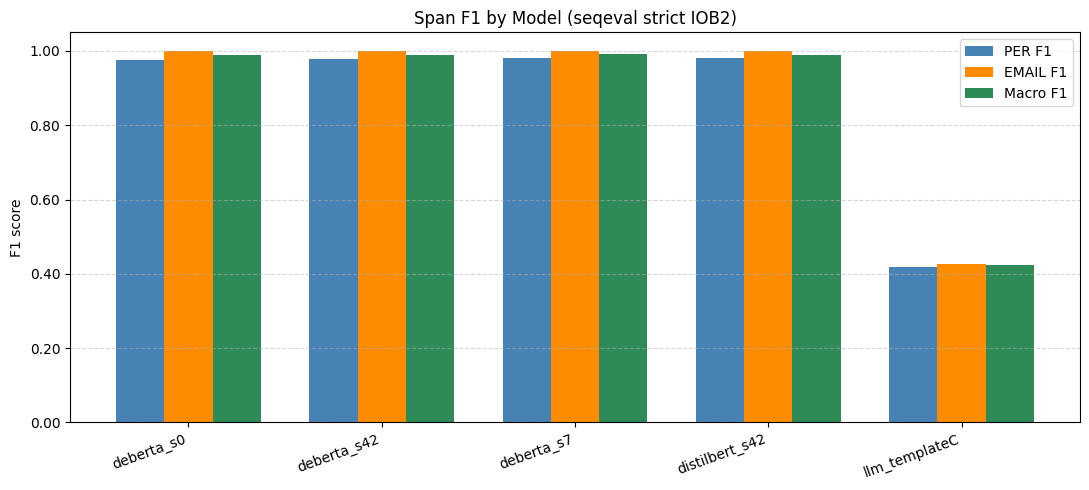

In [5]:
if 'df_f1' not in globals() or df_f1.empty:
    print('Skipping F1 plot: no model metrics available.')
else:
    models = df_f1.index.tolist()
    x = np.arange(len(models))
    width = 0.25

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x - width, df_f1['PER F1'].fillna(0), width, label='PER F1', color='steelblue')
    ax.bar(x, df_f1['EMAIL F1'].fillna(0), width, label='EMAIL F1', color='darkorange')
    ax.bar(x + width, df_f1['Macro F1'].fillna(0), width, label='Macro F1', color='seagreen')

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20, ha='right')
    ax.set_ylabel('F1 score')
    ax.set_title('Span F1 by Model (seqeval strict IOB2)')
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


## Token Error Rates - Binary FPR and FNR Decomposed by Entity Type

Binary framing: a token is PII if its tag is not `O`.
Per-entity rates isolate PER and EMAIL prediction errors independently.

EMAIL FNR highlights a key gap: LLaMA misses 36.7% of email tokens vs DeBERTa's 0.1%, explaining most of the macro F1 difference between the two model families.

In [6]:
token_res = ev.compute_token_rates(model_preds)

rows_tr = []
for k, m in sorted(token_res.items()):
    rows_tr.append({
        'Model': k,
        'FPR': m.get('fpr'),
        'FNR': m.get('fnr'),
        'PER FPR': m.get('per_fpr'),
        'PER FNR': m.get('per_fnr'),
        'EMAIL FPR': m.get('email_fpr'),
        'EMAIL FNR': m.get('email_fnr'),
    })

df_tr = pd.DataFrame(rows_tr)
if df_tr.empty:
    print('No token-level rows available.')
else:
    df_tr = df_tr.set_index('Model')
    display(df_tr.style.format('{:.4f}', na_rep='N/A').background_gradient(cmap='YlOrRd_r', axis=0))


,FPR,FNR,PER FPR,PER FNR,EMAIL FPR,EMAIL FNR
Model,,,,,,
deberta_s0,0.0018,0.0086,0.0017,0.0110,0.0000,0.0000
deberta_s42,0.0017,0.0076,0.0016,0.0095,0.0000,0.0011
deberta_s7,0.0015,0.0071,0.0014,0.0092,0.0000,0.0000
distilbert_s42,0.0012,0.0073,0.0011,0.0093,0.0000,0.0004
llm_templateC,0.1653,0.0760,0.1226,0.1002,0.0457,0.3668


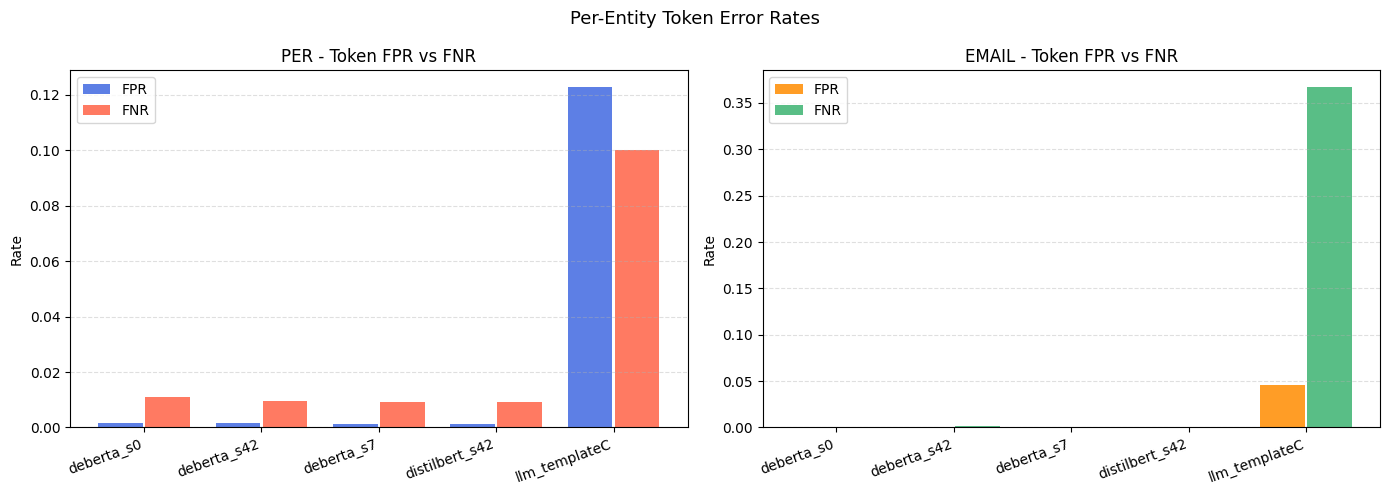

In [7]:
if 'df_tr' not in globals() or df_tr.empty:
    print('Skipping token-rate plot: no token metrics available.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    for ax, entity, fpr_col, fnr_col, color_fpr, color_fnr in [
        (axes[0], 'PER', 'PER FPR', 'PER FNR', 'royalblue', 'tomato'),
        (axes[1], 'EMAIL', 'EMAIL FPR', 'EMAIL FNR', 'darkorange', 'mediumseagreen'),
    ]:
        x = np.arange(len(df_tr))
        ax.bar(x - 0.2, df_tr[fpr_col].fillna(0), 0.38, label='FPR', color=color_fpr, alpha=0.85)
        ax.bar(x + 0.2, df_tr[fnr_col].fillna(0), 0.38, label='FNR', color=color_fnr, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(df_tr.index, rotation=20, ha='right')
        ax.set_title(f'{entity} - Token FPR vs FNR')
        ax.set_ylabel('Rate')
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.suptitle('Per-Entity Token Error Rates', fontsize=13)
    plt.tight_layout()
    plt.show()


## Masking Pipeline - Character-Offset Redaction and PII Leak Rate

`MaskingPipeline` aligns predicted IOB2 tags to character offsets in the original sentence string, then replaces each PER span with `[NAME]` and each EMAIL span with `[EMAIL]`. Replacement is applied right-to-left so earlier offsets stay valid after each substitution.

A record leaks if any gold entity string (case-insensitive) still appears as a substring in the masked output, meaning the model failed to detect and redact it.

In [8]:
leak_res = ev.compute_leak_rates(model_preds)

rows_lr = []
for k, v in sorted(leak_res.items()):
    rows_lr.append({
        'Model': k,
        'Leak Rate': v.get('leak_rate'),
        'Leaked': v.get('leaked_count'),
        'Total': v.get('total_count'),
        'Reconstructed Seqs': v.get('reconstructed_sequence_count', 0),
    })

df_lr = pd.DataFrame(rows_lr)
if df_lr.empty:
    print('No leak-rate rows available.')
else:
    df_lr = df_lr.set_index('Model')
    display(df_lr.style.format({'Leak Rate': '{:.4f}', 'Leaked': '{:,}', 'Total': '{:,}'})
        .background_gradient(subset=['Leak Rate'], cmap='YlOrRd_r'))


,Leak Rate,Leaked,Total,Reconstructed Seqs
Model,,,,
deberta_s0,0.0244,89,"3,650",0
deberta_s42,0.0214,78,"3,650",0
deberta_s7,0.0216,79,"3,650",0
distilbert_s42,0.0230,84,"3,650",0
llm_templateC,0.1304,476,"3,650",0


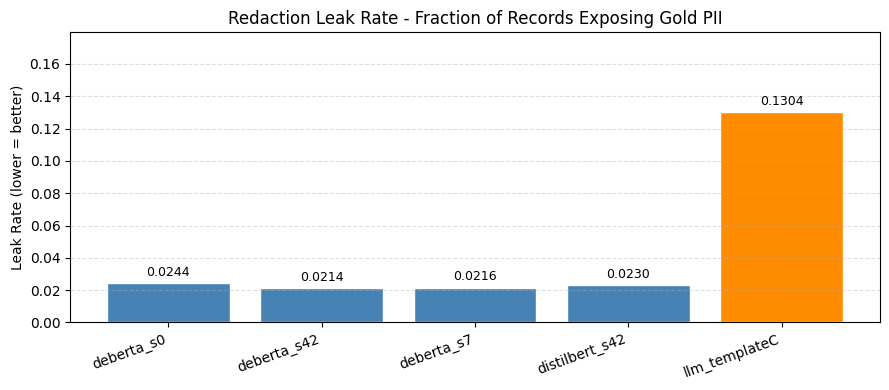

In [9]:
if 'df_lr' not in globals() or df_lr.empty:
    print('Skipping leak-rate plot: no leak-rate metrics available.')
else:
    fig, ax = plt.subplots(figsize=(9, 4))
    models_lr = df_lr.index.tolist()
    leak_vals = df_lr['Leak Rate'].fillna(0).tolist()
    colors = ['steelblue' if 'deberta' in m or 'distilbert' in m else 'darkorange'
              for m in models_lr]
    bars = ax.bar(models_lr, leak_vals, color=colors, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_ylabel('Leak Rate (lower = better)')
    ax.set_title('Redaction Leak Rate - Fraction of Records Exposing Gold PII')
    ax.set_ylim(0, max(leak_vals) * 1.3 + 0.01)
    plt.xticks(rotation=20, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


### Masking Examples - Original Sequence vs Redacted Output

Run the masking pipeline on the first 3 records of each model and display the original sentence alongside its redacted form.

In [10]:
masker = MaskingPipeline()

for model_key in sorted(model_preds.keys())[:2]:
    print(f'=== {model_key} ===')
    for rec in model_preds[model_key][:3]:
        seq = rec.get('sequence') or ' '.join(rec['tokens'])
        tags = rec.get('pred_tags', [])
        n = len(rec['tokens'])
        tags_aligned = (tags + ['O'] * n)[:n]
        try:
            masked = masker.mask_text(seq, rec['tokens'], tags_aligned)
        except ValueError as e:
            masked = f'[ERROR: {e}]'
        print(f'  ORIG  : {seq[:120]}')
        print(f'  MASKED: {masked[:120]}')
        print()

=== deberta_s0 ===
  ORIG  : This Is What the Truth Feels Like " was released on March 18 , 2016 , and debuted at number one on the " Billboard " 200
  MASKED: This Is What the Truth Feels Like " was released on March 18 , 2016 , and debuted at number one on the " Billboard " 200

  ORIG  : Bragg ( bragg.bragg@zoho.com ) diffraction is a consequence of interference between waves reflecting from different crys
  MASKED: [NAME] ( [EMAIL] ) diffraction is a consequence of interference between waves reflecting from different crystal planes .

  ORIG  : Wendy runs after Stan , calling his name , leaving Cartman , cartman.c@icloud.com completely alone .
  MASKED: [NAME] runs after [NAME] , calling his name , leaving [NAME] , [EMAIL] completely alone .

=== deberta_s42 ===
  ORIG  : This Is What the Truth Feels Like " was released on March 18 , 2016 , and debuted at number one on the " Billboard " 200
  MASKED: This Is What the Truth Feels Like " was released on March 18 , 2016 , and debuted 

## Paired Bootstrap - Sentence-Level F1 Resampling to Test DeBERTa vs LLaMA

Compares DeBERTa-v3-small (seed 42) against LLaMA Template C at the sentence level.

**Test statistic:** mean per-sentence span F1
**One-sided alternative:** DeBERTa F1 > LLaMA F1
**Procedure:** N = 1,000 bootstrap resamples, `np.random.seed(42)`

In [11]:
bootstrap = ev.run_bootstrap(model_preds)

if bootstrap:
    print(f"Comparison      : {bootstrap['comparison']}")
    print(f"Observed diff   : {bootstrap['observed_diff_f1']:+.4f}  (DeBERTa - LLaMA)")
    print(f"95% CI          : [{bootstrap['ci_lower_95']:.4f}, {bootstrap['ci_upper_95']:.4f}]")
    print(f"p-value (1-sided): {bootstrap['p_value_one_sided']:.4f}")
    print(f"N sentences     : {bootstrap['n_sentences']}")
    print()
    print(f"Interpretation  : {bootstrap['interpretation']}")
else:
    print('Bootstrap could not be computed (missing deberta_s42 or llm_templateC predictions)')

INFO: Bootstrap: 3650 aligned sentences


Comparison      : deberta_s42_vs_llm_templateC
Observed diff   : +0.4154  (DeBERTa - LLaMA)
95% CI          : [0.4038, 0.4273]
p-value (1-sided): 0.0000
N sentences     : 3650

Interpretation  : DeBERTa significantly outperforms LLaMA (p < 0.05)


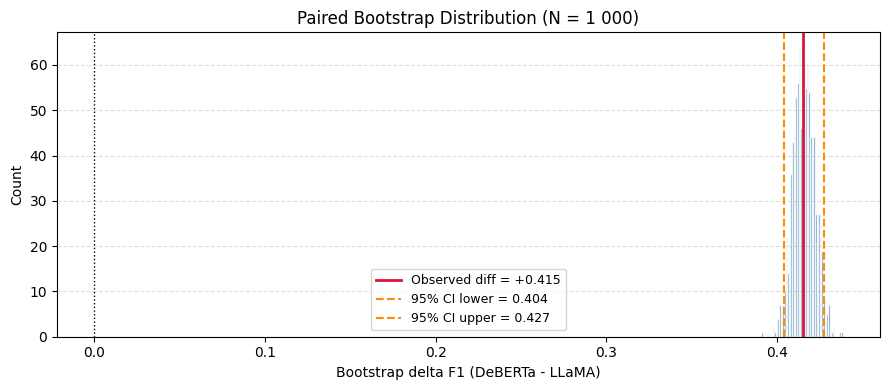

In [12]:
if 'deberta_s42' in model_preds and 'llm_templateC' in model_preds:
    from seqeval.metrics import classification_report as seq_report
    from seqeval.scheme import IOB2

    deb_recs = model_preds['deberta_s42']
    llm_recs = model_preds['llm_templateC']
    n_sent   = min(len(deb_recs), len(llm_recs))

    def _sent_f1(g, p):
        if not any(t != 'O' for t in g) and not any(t != 'O' for t in p):
            return 0.0
        try:
            r = seq_report([g], [p], mode='strict', scheme=IOB2,
                           output_dict=True, zero_division=0)
            return float(r.get('macro avg', {}).get('f1-score', 0.0))
        except Exception:
            return 0.0

    deb_f1s = [_sent_f1(deb_recs[i]['gold_tags'],
                        (deb_recs[i]['pred_tags'] + ['O']*len(deb_recs[i]['gold_tags']))[:len(deb_recs[i]['gold_tags'])])
               for i in range(n_sent)]
    llm_f1s = [_sent_f1(llm_recs[i]['gold_tags'],
                        (llm_recs[i]['pred_tags'] + ['O']*len(llm_recs[i]['gold_tags']))[:len(llm_recs[i]['gold_tags'])])
               for i in range(n_sent)]

    obs_diff = float(np.mean(deb_f1s) - np.mean(llm_f1s))

    np.random.seed(42)
    boot_diffs = []
    for _ in range(1000):
        idx = np.random.choice(n_sent, size=n_sent, replace=True)
        boot_diffs.append(np.mean([deb_f1s[i] for i in idx]) -
                          np.mean([llm_f1s[i] for i in idx]))

    ci_lo = np.percentile(boot_diffs, 2.5)
    ci_hi = np.percentile(boot_diffs, 97.5)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(boot_diffs, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(obs_diff, color='crimson',    lw=2, label=f'Observed diff = {obs_diff:+.3f}')
    ax.axvline(ci_lo,    color='darkorange', lw=1.5, linestyle='--', label=f'95% CI lower = {ci_lo:.3f}')
    ax.axvline(ci_hi,    color='darkorange', lw=1.5, linestyle='--', label=f'95% CI upper = {ci_hi:.3f}')
    ax.axvline(0,        color='black',      lw=1, linestyle=':')
    ax.set_xlabel('Bootstrap delta F1 (DeBERTa - LLaMA)')
    ax.set_ylabel('Count')
    ax.set_title('Paired Bootstrap Distribution (N = 1 000)')
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print('Skipping plot: deberta_s42 or llm_templateC predictions not available')

## Aggregate Comparison Table - Mean and Std Across DeBERTa Seeds vs Single-Seed Baselines

DeBERTa metrics are reported as mean +/- std across seeds 0, 7, and 42 to show stability across random initialization. DistilBERT and LLaMA are single-run baselines. All span F1, token error rate, and leak rate columns are assembled here from the three evaluation passes above.

In [13]:
deberta_keys = sorted(
    [k for k in seqeval_res if k.startswith('deberta_s')],
    key=lambda k: int(k.split('_s')[1])
)

def _ms(vals, d=3):
    v = [x for x in vals if x is not None]
    if not v:
        return 'N/A'
    m, s = float(np.mean(v)), float(np.std(v))
    return f'{m:.{d}f} +/- {s:.{d}f}'

def _f(v, d=3):
    return 'N/A' if v is None else f'{v:.{d}f}'

per_f1s = [seqeval_res[k].get('PER', {}).get('f1') for k in deberta_keys]
email_f1s = [(seqeval_res[k].get('EMAIL') or {}).get('f1') for k in deberta_keys]
macro_f1s = [seqeval_res[k].get('macro_avg', {}).get('f1') for k in deberta_keys]

def _deb_token(field):
    return token_res.get('deberta_s42', {}).get(field)

dist_sr = seqeval_res.get('distilbert_s42', {})
dist_tr = token_res.get('distilbert_s42', {})
dist_lr = leak_res.get('distilbert_s42', {})

llm_sr = seqeval_res.get('llm_templateC', {})
llm_tr = token_res.get('llm_templateC', {})
llm_lr = leak_res.get('llm_templateC', {})

deb_label = (
    f'DeBERTa-v3-small (seeds {[int(k.split("_s")[1]) for k in deberta_keys]})'
    if deberta_keys else 'DeBERTa-v3-small (not loaded)'
)

summary_data = {
    'Metric': [
        'Span F1 - PER',
        'Span F1 - EMAIL',
        'Macro Span F1',
        'Token FPR (binary)',
        'Token FNR (binary)',
        'PER FNR',
        'EMAIL FNR',
        'Redaction Leak Rate',
    ],
    deb_label: [
        _ms(per_f1s),
        _ms(email_f1s),
        _ms(macro_f1s),
        _f(_deb_token('fpr')),
        _f(_deb_token('fnr')),
        _f(_deb_token('per_fnr')),
        _f(_deb_token('email_fnr')),
        _f(leak_res.get('deberta_s42', {}).get('leak_rate')),
    ],
    'DistilBERT-cased (1 seed)': [
        _f((dist_sr.get('PER') or {}).get('f1')),
        _f((dist_sr.get('EMAIL') or {}).get('f1')),
        _f((dist_sr.get('macro_avg') or {}).get('f1')),
        _f(dist_tr.get('fpr')),
        _f(dist_tr.get('fnr')),
        _f(dist_tr.get('per_fnr')),
        _f(dist_tr.get('email_fnr')),
        _f(dist_lr.get('leak_rate')),
    ],
    'LLaMA-3.2-1B (Template C)': [
        _f((llm_sr.get('PER') or {}).get('f1')),
        _f((llm_sr.get('EMAIL') or {}).get('f1')),
        _f((llm_sr.get('macro_avg') or {}).get('f1')),
        _f(llm_tr.get('fpr')),
        _f(llm_tr.get('fnr')),
        _f(llm_tr.get('per_fnr')),
        _f(llm_tr.get('email_fnr')),
        _f(llm_lr.get('leak_rate')),
    ],
}

df_summary = pd.DataFrame(summary_data).set_index('Metric')
df_summary


,"DeBERTa-v3-small (seeds [0, 7, 42])",DistilBERT-cased (1 seed),LLaMA-3.2-1B (Template C)
Metric,,,
Span F1 - PER,0.979 +/- 0.002,0.982,0.419
Span F1 - EMAIL,1.000 +/- 0.000,0.999,0.426
Macro Span F1,0.989 +/- 0.001,0.990,0.423
Token FPR (binary),0.002,0.001,0.165
Token FNR (binary),0.008,0.007,0.076
PER FNR,0.009,0.009,0.100
EMAIL FNR,0.001,0.000,0.367
Redaction Leak Rate,0.021,0.023,0.130


## Save Outputs - Serializing Results, Bootstrap, and Day 5 Summary to Disk

Writes three artifacts: `reports/results.json` (all numeric metrics, machine-readable), `predictions/bootstrap_results.json` (bootstrap distribution summary and p-value), and `results/day5/day5_summary.md` (human-readable comparison table). On Kaggle these paths resolve under `/kaggle/working/` and are pulled back locally via `kaggle/evaluation/pull_results.sh`.

In [14]:
if not model_preds:
    raise RuntimeError('No predictions loaded; nothing to save.')

if bootstrap:
    out = ev.BOOTSTRAP_OUT
    out.parent.mkdir(parents=True, exist_ok=True)
    out.write_text(json.dumps(bootstrap, indent=2), encoding='utf-8')
    print(f'Saved bootstrap results: {out}')

full_results = ev.build_results_json(model_preds, seqeval_res, token_res, leak_res, bootstrap)
ev.REPORTS_DIR.mkdir(parents=True, exist_ok=True)
ev.RESULTS_JSON.write_text(json.dumps(full_results, indent=2), encoding='utf-8')
print(f'Saved results: {ev.RESULTS_JSON}')

ev.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
summary_md = ev.build_summary_md(full_results, bootstrap, load_warnings)
ev.SUMMARY_MD.write_text(summary_md, encoding='utf-8')
print(f'Saved day5 summary: {ev.SUMMARY_MD}')

print('\nDay 5 outputs written.')


Saved bootstrap results: E:\Projects\pii_masking\predictions\bootstrap_results.json
Saved results: E:\Projects\pii_masking\reports\results.json
Saved day5 summary: E:\Projects\pii_masking\results\day5\day5_summary.md

Day 5 outputs written.


## Inline Summary - Human-Readable Comparison Table from Serialized Artifacts

Reads `results/day5/day5_summary.md` from disk and renders it as a formatted Markdown table in the notebook output. This confirms the save was successful and gives a final at-a-glance view of all model results without re-running any computation.

In [15]:
from IPython.display import Markdown, display

if ev.SUMMARY_MD.exists():
    display(Markdown(ev.SUMMARY_MD.read_text(encoding='utf-8')))
else:
    print(f'Summary file not found yet: {ev.SUMMARY_MD}')


# Day 5 Evaluation Summary

DeBERTa seeds evaluated: [0, 7, 42]  (token-level rates and leak rate reported for seed 42)

## Main Comparison Table

| Metric | DeBERTa-v3-small (mean±std) | DistilBERT-cased (1 seed) | LLaMA-3.2-1B-Instruct (Template C) |
|-------------------------|------------------------------|---------------------------|--------------------------------------|
| Span F1 — PER           | 0.979±0.002 | 0.982 | 0.419 |
| Span F1 — EMAIL         | 1.000±0.000 | 0.999 | 0.426 |
| Macro Span F1           | 0.989±0.001 | 0.990 | 0.423 |
| Token FPR (binary)      | 0.002 | 0.001 | 0.165 |
| Token FNR (binary)      | 0.008 | 0.007 | 0.076 |
| PER FNR                 | 0.009 | 0.009 | 0.100 |
| EMAIL FNR               | 0.001 | 0.000 | 0.367 |
| Redaction Leak Rate     | 0.021 | 0.023 | 0.130 |

## Statistical Comparison (DeBERTa vs LLaMA)

- Observed F1 difference: 0.415
- 95% CI: [0.404, 0.427]
- p-value (one-sided): 0.000
- Conclusion: significant at α=0.05
